<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>code</h1>

In [1]:
import numpy as np
from scipy.stats import norm,t

In [2]:
np.random.seed(1)

In [3]:
N = 1000 # number of samples
mu = 5 # true mean
sigma = 2 # true standard deviation
# reverse of standardisation
# data has mean mu and sd sigma
X = np.random.randn(N)*sigma + mu

In [4]:
# implement Z-confidence interval
# gamma = 95%

mu_hat = np.mean(X)
sigma_hat = np.std(X,ddof=1)

z_left = norm.ppf(0.025)
z_right = norm.ppf(0.975)

lower = mu_hat + z_left*sigma_hat / np.sqrt(N)
upper = mu_hat + z_right*sigma_hat / np.sqrt(N)

print(mu_hat,lower,upper)

# we see that our mean is equal to about 5, which is expected
# also, we see that the interval between the lower and upper endpoints contains the true mean, 5
# we expected this to be the case about 95% of the time
# or in other times every 19/20 times we run this block of code

5.077624952319204 4.955959806754385 5.199290097884023


In [5]:
# t-confidence interval

# same as before
mu_hat = np.mean(X)
sigma_hat = np.std(X,ddof=1)

# again we use ppf, which refers to the inverse CDF
# unlike the standard normal, the t-distribution requires the degrees of freedom parameter
# as we mentioned, thats equal to N-1
t_left = t.ppf(0.025,df=N-1)
t_right = t.ppf(0.975,df=N-1)

# same as before
# with t_left, t_right instead of z_left, z_right
lower = mu_hat + t_left*sigma_hat / np.sqrt(N)
upper = mu_hat + t_right*sigma_hat / np.sqrt(N)

print(mu_hat,lower,upper)

# the estimated mean is the same, not changed from before
# also the lower and upper endpoints are extemely close to the z-interval

5.077624952319204 4.9558122244324165 5.199437680205992


In [9]:
# now we want to do an experiment to test hte interpretation of confidence interval
# according to the frequentist interpretation of CI, 95% of the time the interval will contain the true mean
# this means that 5% of the time, the interval will no contain the true mean

def experiment():
    X = np.random.randn(N)*sigma + mu
    mu_hat = np.mean(X)
    sigma_hat = np.std(X,ddof=1)
    t_left = t.ppf(0.025,df=N-1)
    t_right = t.ppf(0.975,df=N-1)
    lower = mu_hat + t_left *sigma_hat / np.sqrt(N)
    upper = mu_hat + t_right *sigma_hat / np.sqrt(N)
    return mu > lower and mu < upper # check if mu in range

In [10]:
def multi_experiment(M):
    return np.mean([experiment() for _ in range(M)])

In [11]:
multi_experiment(10000)
# so we see that, our of 10,000 trials
# the CI contain the true mean about 95% of the time as we expected

0.9506

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Code</h1>

In [3]:
import numpy as np
from scipy.stats import norm
from statsmodels.stats.weightstats import ztest

In [4]:
# now we are going to implement the z-test ourselves
# then cross-reference it with what stats models give us
# to make sure that we get the same asnwer
np.random.seed(0)

In [21]:
N = 100
mu = 0.2
sigma = 1
x = np.random.randn(N)*sigma + mu

In [22]:
# two sided test 
# if we check the documentation, we will see that the reference value (what we are comparing to) = 0
# so if we want to compare to any other, we can pass this to value
ztest(x)

(1.7981205884493316, 0.07215790025630599)

In [23]:
# now for our implementation
# so this is just applying the equations
mu_hat = np.mean(x)
sigma_hat = x.std(ddof=1)
z = mu_hat/(sigma_hat/np.sqrt(N))
# this can be norm.sf(np.abs(z))
# also may give more accurate results
p_right = 1 - norm.cdf(np.abs(z))
p_left = norm.cdf(-np.abs(z))
p = p_right + p_left
z,p
# slight difference is due to numerical precision in floating point numbers

(1.7981205884493316, 0.07215790025630597)

In [27]:
# one sided test
# since this is one-sided
# we need to check whether this is the greater than case or less than case
# since we know that mu is actually greater than 0 (mu=0.2)
# it should make more sense to check the greater than case
ztest(x,alternative='larger')
# note how we get the same value of z
# but half the value of p

(1.7981205884493316, 0.036078950128152994)

In [29]:
# again, here is our implementation
mu_hat = x.mean()
sigma_hat = x.std(ddof=1)
z = mu_hat / (sigma_hat/np.sqrt(N)) # mu0 = 0, no need to subtract
p = 1 - norm.cdf(z)
z,p

(1.7981205884493316, 0.03607895012815299)

In [32]:
# what happens if we pass in a different reference value mu0
mu0 = 0.2 # same as mu
# this means that the null hypotheses is actually true
ztest(x,value=mu0)
# remember
# even though we know that the null hypothesis is true (since we created the data)
# we can not accept the null hypothesis
# we can only fain to reject the null hypothesis

(-0.12053181455609435, 0.9040618789770263)

In [34]:
# same as the above 2-sided test
# but this time we subtract mu
mu_hat = np.mean(x)
sigma_hat = x.std(ddof=1)
z = (mu_hat-mu0)/(sigma_hat/np.sqrt(N))
p_right = 1 - norm.cdf(np.abs(z))
p_left = norm.cdf(-np.abs(z))
p = p_right + p_left
z,p

(-0.12053181455609435, 0.9040618789770263)

In [ ]:
# we may recall that the purpose of the significance level
# is to control the rate of false alarms
# that means that we reject the null hypothesis
# even though the null hypothesis is true
# or in less technical terms, we detect some significant effect
# even though when there is no such effect
# so one thing we can try to do is play around with script or run this multiple times
# in order to generate a false positive

In [36]:
# next, we are doing a two sample test
# we will starrt by creating our data and our variables

N0 = 100
mu0 = 0.2
sigma0 = 1
x0 = np.random.randn(N0)*sigma0 + mu0

N1 = 100
mu1 = 0.5
sigma1 = 1
x1 = np.random.randn(N1)*sigma1 + mu1

In [37]:
ztest(x0,x1)
# this is one example of failing to reject the null hypothesis
# with a significance threshold of 5%
# even though we know that the alternative is true

# all three variables (mu,sigma,N) above contribute to this
# we may not have enough data
# or the means may not far enough apart
# or the variances migh be too large
# all of these things contribute to the z statistic

(-2.972669008209414, 0.002952226258536032)

In [39]:
# here comes our implementation
# we transform our two-sample test into a one-sample test
mu_hat0 = x0.mean()
mu_hat1 = x1.mean()
y_mu_hat = mu_hat0 - mu_hat1
var_hat0 = x0.var(ddof=1)
var_hat1 = x1.var(ddof=1)
s_hat = np.sqrt(var_hat0/N0 + var_hat1/N1)
z = y_mu_hat/s_hat # reference value is 0
p_right = 1-norm.cdf(np.abs(z))
p_left = norm.cdf(-np.abs(z))
p = p_left + p_right
z,p
# note that if we had done mu_hat1 - mu_hat0
# we would have gotten the same z value but with the opposite sign
# this is fine, since it depends on which group do we consider 1 and which do we consider 2

(-2.972669008209414, 0.002952226258536002)

In [41]:
# finally, we want to provide more intuition behind the idea of frequentist statistics
# lets recall the meaning of the significance threshold
# by using a mean of 5%, it means that 5% of the time we will reject the null hypothesis
# even when the null hypothesis is really true
# we call such an event a false alarm

In [42]:
num_tests = 10000 # number of runs
results = np.zeros(num_tests)

for i in range(num_tests):
    # both x1 and x2 are 100 samples from the standard normal
    x1 = np.random.randn(100)
    x2 = np.random.randn(100)
    z,p = ztest(x1,x2)
    results[i] = (p<0.05) # 1 if we reject the null hypothesis
print(results.mean())

# its also worth mentioning that
# we cant simply change the false alarm rate
# without affecting our ability to detect a significant effect
# suppose that we want our false alarm rate to be 1% instead of 5%
# then we require a p value of less than 1% in order to detect a significant effect
# however as we have learned, in order to obtain a smaller p value
# this might require more data, a stronger effect or a smaller variance

0.0491


<h1>code</h1>

In [48]:
# now we will apply our z-test to real data
# we will be looking at the famous titanic dataset 
# (first time to hear about it though, tho :)
# (the dataset not the titanic ;)
import pandas as pd
import numpy as np
# seaborn will help us draw density plots
# which are useful for visualising the distribution of our data
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
# we can find the data on kaggle
data = pd.read_csv('datasets/titanic/titanic_train.csv')

In [53]:
data.head()
# we will be interested in the groups of passengers who survived and who did not survive

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [55]:
# ok, our goal in this test is to check 
# whether or not there is a difference in the fare each passenger paid between the two groups
# that is to say, is the fare different among those who survived and those who did not survive

# get the fare passengers who survived
x1 = data[data['Survived']==1]['Fare'].dropna().to_numpy()

# same for those who did not surviv
x2 = data[data['Survived']==0]['Fare'].dropna().to_numpy()

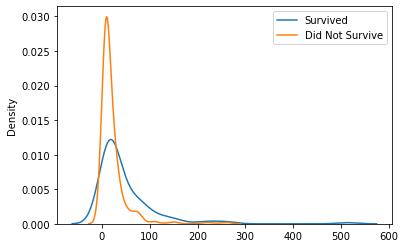

In [58]:
# next we do a density plot for the two groups
# basically this is like a histogram
# but it yeilds a smoother curve
sns.kdeplot(x1,label='Survived')
sns.kdeplot(x2,label='Did Not Survive')
plt.legend()
plt.show()

In [59]:
# so we see that, based on visual inspection only
# there doesnot seem to be that much of a difference between the two groups
# there does seem to be a highe peek for the 'Did Not Survive' group
# but this does not imply that the means are different

In [61]:
# lets check the means
x1.mean(),x2.mean()

(48.39540760233918, 22.117886885245902)

In [63]:
# so there does seem to be a big difference in the means of the two groups
# which was not visible from the plot
# since the range of values was so large
# however, this doesnot imply the the difference is significant
# since it still depends on the variance and the number of samples

In [64]:
ztest(x1,x2)

(7.939191660871055, 2.035031103573989e-15)

In [65]:
# as we can see, we get a p value on the order e-15
# this means that the result we observed is very significant
# and we would reject the Null hypothesis
# that the average fair of the two groups is the same

<h1>Math</h1>

In [66]:
# here is another example on click through rates
# we compare between two ads A and B

In [70]:
import pandas
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [71]:
# so our rule "All data is the same"
# allows us to use exactly the above code
data = pd.read_csv('datasets/advertisement_clicks.csv')

In [72]:
data.head()

,advertisement_id,action
0,B,1
1,B,1
2,A,0
3,B,0
4,A,1


In [73]:
# action = 1, means use saw ad and clicked
# action = 0, means user saw ad and did not click

# ok, our goal in this test is to check 
# whether or not there is a statistical difference
# between the click through rates (CTR) of ads A and B

# get data for ad A
x1 = data[data['advertisement_id']=='A']['action'].to_numpy()

# same for add B
x2 = data[data['advertisement_id']=='B']['action'].to_numpy()

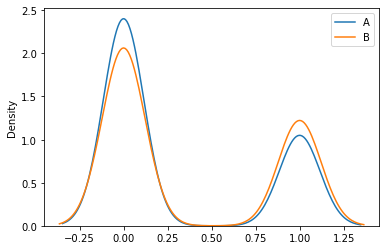

In [74]:
sns.kdeplot(x1,label='A')
sns.kdeplot(x2,label='B')
plt.legend()
plt.show()

In [75]:
x1.mean(),x2.mean()

(0.304, 0.372)

In [76]:
ztest(x1,x2)

(-3.2211732138019786, 0.0012766696301529544)

In [77]:
# since p< 5%
# we can reject the null hypothesis
# that states that both means are the same

In [81]:
ztest(x1,x2,alternative='smaller')

(-3.2211732138019786, 0.0006383348150764772)

In [82]:
# again, since p< 5%
# we accept the null statement
# that muA < muB
# which we know is true
# muA = 0.304 , muB = 0.372

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted